In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('loan_approval_data.csv')
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## Handle Missing Values


In [5]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns
categorical_cols, numerical_cols

(Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
        'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
       dtype='str'),
 Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
        'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
        'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
       dtype='str'))

In [7]:
from sklearn.impute import SimpleImputer

# Impute numerical columns with mean
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Impute categorical columns with most_frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## EDA - Exploratory Data Analysis


Text(0.5, 1.0, 'Is loan Approved or not?')

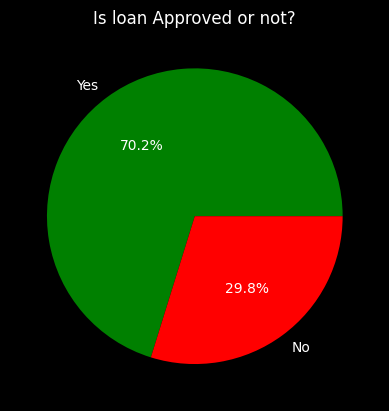

In [8]:
import matplotlib.pyplot as plt

#how balanced our classes are

classes_count = df["Loan_Approved"].value_counts()
plt.pie(
    classes_count,
    labels=["Yes", "No"],
    autopct="%1.1f%%",
    colors=["green", "red"]
)
plt.title("Is loan Approved or not?")

[Text(0, 2, '621'), Text(0, 2, '379')]

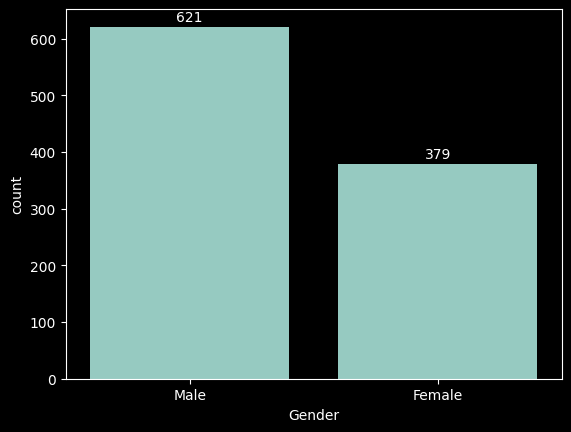

In [40]:
import seaborn as sns

gender_cnt = df["Gender"].value_counts()

ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0], padding=2)

### Check outlier


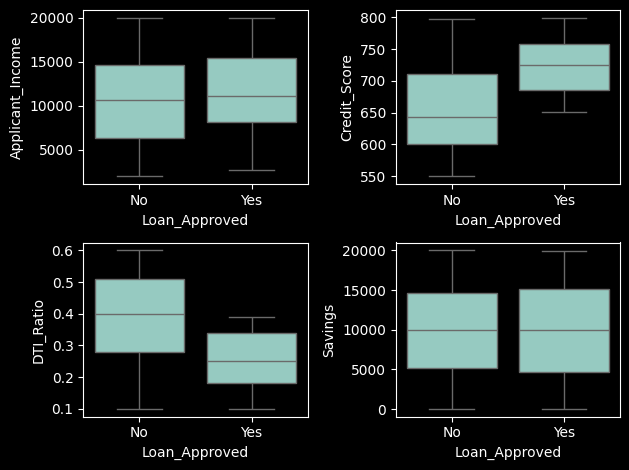

In [9]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

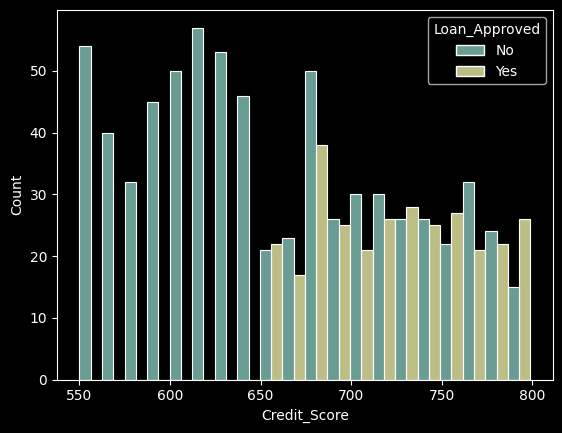

In [11]:
sns.histplot(
    data=df,
    x="Credit_Score",
    bins= 20,
    hue="Loan_Approved",
    multiple="dodge"
    )

### remove unnecessery cols


In [18]:
# df = df.drop(["Applicant_ID"], axis=1)
df.head()
print(df.columns)

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='str')


### Encoding

- LabelEncoder(Ordinal) - Assign an integer to each category.
- OneHotEncoder(Nominal) - Creates Binary Columns for each Category.


In [17]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [ ]:
oneHot_cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area", "Gender","Employer_Category"]

one = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = one.fit_transform(df[oneHot_cols])
encoded_df = pd.DataFrame(encoded, columns=one.get_feature_names_out(oneHot_cols), index=df.index)
df = pd.concat([df.drop(columns=oneHot_cols), encoded_df], axis=1)
df.head()


## Correlation Heatmap


<Axes: >

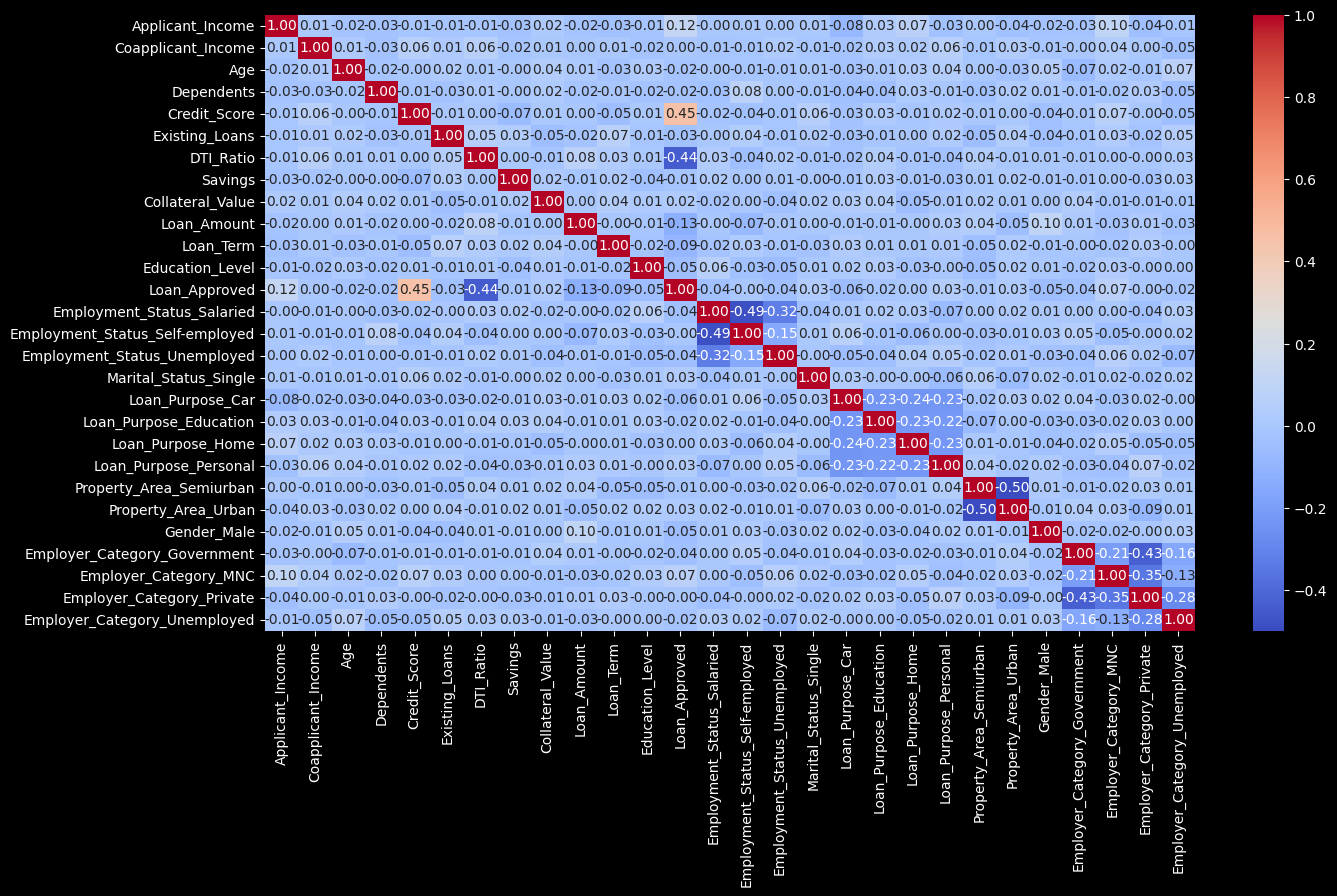

In [30]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()
corr_matrix

plt.figure(figsize=(15, 8))
sns.heatmap(
    data= corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

## Train-Test Split + Feature Scaling


In [37]:
X = df.drop("Loan_Approved", axis=1)
y = df["Loan_Approved"]

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


## Scaling


In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

## Train & Evaluate Model


### Logistic Regression


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, confusion_matrix

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

# Evaluation
print("precision_score", precision_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))


precision_score 0.7833333333333333
accuracy_score 0.865
f1_score 0.7768595041322314
recall_score 0.7704918032786885
confusion_matrix [[126  13]
 [ 14  47]]


### KNN Classifier


In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("precision_score", precision_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

precision_score 0.6274509803921569
accuracy_score 0.76
f1_score 0.5714285714285714
recall_score 0.5245901639344263
confusion_matrix [[120  19]
 [ 29  32]]


### Naive Bayes


In [48]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("precision_score", precision_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

precision_score 0.8035714285714286
accuracy_score 0.865
f1_score 0.7692307692307693
recall_score 0.7377049180327869
confusion_matrix [[128  11]
 [ 16  45]]


# Feature Engineering


In [55]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_square"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "DTI_Ratio", "Credit_Score"])
y = df["Loan_Approved"]

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.20304575,
        -0.6997447 ,  0.55631184],
       [ 1.00971366,  0.58995935,  0.18392964, ...,  0.27361433,
        -1.22139086,  0.91796318],
       [-0.67557096, -0.54558674,  1.09887608, ...,  1.96220124,
        -0.99089704, -0.42378239],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -1.15611611,
         1.86593072, -0.42879519],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.18389941,
        -0.38425817, -0.10098701],
       [-0.73647272, -1.24497436,  0.73289751, ...,  0.19234545,
        -1.51790551, -0.49724819]], shape=(200, 28))

In [57]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)

# Evaluation
print("precision_score", precision_score(y_test, y_pred))
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred))
print("recall_score", recall_score(y_test, y_pred))
print("confusion_matrix", confusion_matrix(y_test, y_pred))

precision_score 0.7846153846153846
accuracy_score 0.88
f1_score 0.8095238095238095
recall_score 0.8360655737704918
confusion_matrix [[125  14]
 [ 10  51]]
